<a href="https://colab.research.google.com/github/Harman061/Liquidity-Market-Credit-Risk-Projects/blob/Main/Market_Risk_VaR_Calculation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sqlite3


In [9]:

# Simulation parameters
np.random.seed(42)  # For reproducibility
num_simulations = 10000  # Number of Monte Carlo simulations
timesteps = 252  # 1 year of daily returns
initial_portfolio_value = 1_000_000  # $1 million portfolio


In [10]:

# Portfolio stocks and weights
stocks = ['AAPL', 'GOOGL', 'MSFT', 'AMZN']
weights = np.array([0.3, 0.3, 0.2, 0.2])  # Portfolio allocation


In [11]:

# Simulated daily returns (mean and std dev approximated)
mean_returns = np.array([0.0005, 0.0004, 0.0006, 0.0003])  # Approximate daily returns
std_devs = np.array([0.02, 0.025, 0.018, 0.03])  # Approximate daily volatilities

# Generate correlated random returns
cov_matrix = np.diag(std_devs) @ np.random.normal(size=(len(stocks), len(stocks))) @ np.diag(std_devs)
random_returns = np.random.multivariate_normal(mean_returns, cov_matrix, (num_simulations, timesteps))

# Portfolio value simulation
portfolio_returns = random_returns @ weights.T  # Weighted sum of returns
portfolio_values = initial_portfolio_value * (1 + portfolio_returns).cumprod(axis=1)


<ipython-input-11-c7295532baeb>:7: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  random_returns = np.random.multivariate_normal(mean_returns, cov_matrix, (num_simulations, timesteps))


In [12]:

# Calculate VaR at 95% confidence level
final_values = portfolio_values[:, -1]  # Portfolio values at last timestep
var_95 = np.percentile(final_values, 5)  # 5th percentile for 95% VaR
VaR = initial_portfolio_value - var_95  # Value at Risk

print(f"Estimated 1-day 95% Value at Risk (VaR): ${VaR:,.2f}")


Estimated 1-day 95% Value at Risk (VaR): $321,238.84


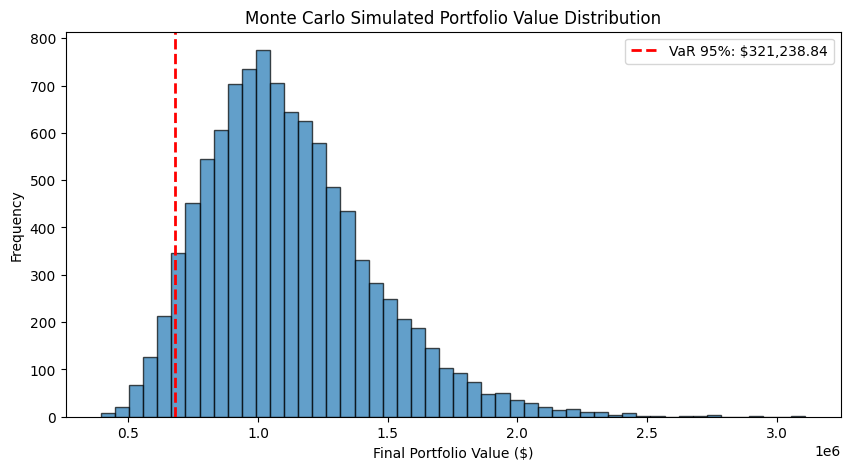

In [13]:

# Plot distribution of portfolio values
plt.figure(figsize=(10, 5))
plt.hist(final_values, bins=50, edgecolor='k', alpha=0.7)
plt.axvline(var_95, color='r', linestyle='dashed', linewidth=2, label=f"VaR 95%: ${VaR:,.2f}")
plt.title("Monte Carlo Simulated Portfolio Value Distribution")
plt.xlabel("Final Portfolio Value ($)")
plt.ylabel("Frequency")
plt.legend()
plt.show()


In [14]:

# Automate risk reporting using SQLite
conn = sqlite3.connect("risk_reports.db")
cursor = conn.cursor()
cursor.execute("""
    CREATE TABLE IF NOT EXISTS risk_report (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        simulation_runs INTEGER,
        initial_value REAL,
        var_95 REAL,
        calculated_on TIMESTAMP DEFAULT CURRENT_TIMESTAMP
    )
""")

cursor.execute("""
    INSERT INTO risk_report (simulation_runs, initial_value, var_95)
    VALUES (?, ?, ?)
""", (num_simulations, initial_portfolio_value, VaR))

conn.commit()
conn.close()
print("Risk report saved to database!")


Risk report saved to database!
